In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("../Output/data for gentrification classification.csv")

In [16]:
df.count()

LSOA21CD                    4994
delta_property_sales        4994
pct_minority_ethnic_2011    4994
pct_minority_ethnic_2021    4994
delta_minority_ethnic       4994
pct_owner_occupied_2011     4994
pct_owner_occupied_2021     4994
delta_owner_occupied        4994
pct_social_rented_2011      4994
pct_social_rented_2021      4994
delta_social_rented         4994
pct_private_rented_2011     4994
pct_private_rented_2021     4994
delta_private_rented        4994
pct_renters_2011            4994
pct_renters_2021            4994
delta_renters               4994
pct_high_education_2011     4994
pct_high_education_2021     4994
delta_high_education        4994
pct_high_sec_2011           4994
pct_high_sec_2021           4994
delta_high_sec              4994
pct_low_sec_2011            4994
pct_low_sec_2021            4994
delta_low_sec               4994
pct_professional_2011       4994
pct_professional_2021       4994
delta_professional          4994
pct_low_skill_2011          4994
pct_low_sk

In [17]:
def classify_gentrification_final_5(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
                'delta_property_sales', 
                'pct_minority_ethnic_2011', 'pct_minority_ethnic_2021', 'delta_minority_ethnic',
                'pct_professional_2011', 'pct_professional_2021', 'delta_professional', 
                'pct_owner_occupied_2011', 'pct_owner_occupied_2021', 'delta_owner_occupied',
                'pct_social_rented_2011', 'pct_social_rented_2021', 'delta_social_rented',
                'pct_private_rented_2011', 'pct_private_rented_2021', 'delta_private_rented',
                'pct_renters_2011', 'pct_renters_2021', 'delta_renters',
                'pct_high_education_2011','pct_high_education_2021','delta_high_education',
                'pct_low_skill_2011', 'pct_low_skill_2021', 'delta_low_skill',
                'pct_high_sec_2011', 'pct_high_sec_2021', 'delta_high_sec',
                'pct_low_sec_2011', 'pct_low_sec_2021', 'delta_low_sec'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
        # Class 0: Affluent and Middle Class

        if row['pct_low_sec_2021'] <  1.25 * q['pct_low_sec_2021'][0.5]:         # This step is try to find the alternatives to low-income population classification standard. 
            affluent_conditions = [                                               # Since London has a higher proportion of professional occupations than the whole UK, so i use the coefficient 1.25.
                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.5],
                row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5],
                
            ]
            if sum(affluent_conditions) >= 1:
                df.at[idx, 'gentrification_class'] = 'Class 0 - Affluent and Middle Class'
                continue

        # Class 4: Ongoing Gentrification
        vulnerable_2011 = [
            row['pct_high_education_2011'] < q['pct_high_education_2011'][0.5],
            row['pct_renters_2011'] > q['pct_renters_2011'][0.5],
            row['pct_minority_ethnic_2011'] > q['pct_minority_ethnic_2011'][0.5],
        ]
        hot_market_2011_2021 = [
            row['delta_property_sales'] > q['delta_property_sales'][0.5],
            row['delta_renters'] > q['delta_renters'][0.5]
        ]
        demographic_change = [
            row['delta_high_education'] > q['delta_high_education'][0.5],
            row['delta_professional'] > q['delta_professional'][0.5],
            row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
        ]
        if sum(vulnerable_2011) >= 2 and sum(hot_market_2011_2021) >= 1 and sum(demographic_change) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 4 - Ongoing Gentrification'
            continue

        # Class 2: Ongoing Displacement
        if row['delta_low_sec'] < 0 and (sum(vulnerable_2011) + sum(hot_market_2011_2021) + sum(demographic_change)) >= 2:
            df.at[idx, 'gentrification_class'] = 'Class 2 - Ongoing Displacement'
            continue

        # Class 3: At risk of gentrification
        vulnerable_2021 = [
            row['pct_high_education_2021'] < q['pct_high_education_2021'][0.5],
            row['pct_renters_2021'] > q['pct_renters_2021'][0.5],
            row['pct_minority_ethnic_2021'] > q['pct_minority_ethnic_2021'][0.5],
        ]
        if sum(vulnerable_2021) >= 2 and sum(hot_market_2011_2021) >= 1:
            df.at[idx, 'gentrification_class'] = 'Class 3 - At Risk of Gentrification'
            continue

        # Class 1: Stable Low-income
        df.at[idx, 'gentrification_class'] = 'Class 1 - Stable Low-income'

    return df[['LSOA21CD', 'gentrification_class']]

In [18]:
def classify_gentrification_final_7(df):
    
    # Precompute quantiles for each variable
    q = {}
    quantiles = [0.25, 0.5, 0.75]
    variables = [
                'delta_property_sales', 
                'pct_minority_ethnic_2011', 'pct_minority_ethnic_2021', 'delta_minority_ethnic',
                'pct_professional_2011', 'pct_professional_2021', 'delta_professional', 
                'pct_owner_occupied_2011', 'pct_owner_occupied_2021', 'delta_owner_occupied',
                'pct_social_rented_2011', 'pct_social_rented_2021', 'delta_social_rented',
                'pct_private_rented_2011', 'pct_private_rented_2021', 'delta_private_rented',
                'pct_renters_2011', 'pct_renters_2021', 'delta_renters',
                'pct_high_education_2011','pct_high_education_2021','delta_high_education',
                'pct_low_skill_2011', 'pct_low_skill_2021', 'delta_low_skill',
                'pct_high_sec_2011', 'pct_high_sec_2021', 'delta_high_sec',
                'pct_low_sec_2011', 'pct_low_sec_2021', 'delta_low_sec'
    ]
    for var in variables:
        q[var] = df[var].quantile(q=quantiles)

    # Initialize classification column
    df['gentrification_class'] = None

    for idx, row in df.iterrows():
            
        # Determining whether a region is affluent in 2011                             
        affluent_2011 = False                                                                  # This step is try to find the alternatives to low-income population classification standard.
        if row['pct_low_sec_2011'] < 1.25 * q['pct_low_sec_2011'][0.5]:                        # Since London has a higher proportion of professional occupations than the whole UK, so i use the coefficient 1.25.
            affluent_conditions_2011 = [
                row['pct_owner_occupied_2011'] > q['pct_owner_occupied_2011'][0.5],
                row['pct_social_rented_2011'] < q['pct_social_rented_2011'][0.5],
            ]
            if sum(affluent_conditions_2011) >= 1:
                affluent_2011 = True

        # Determining whether a region is affluent in 2021
        affluent_2021 = False
        if row['pct_low_sec_2021'] < 1.25 * q['pct_low_sec_2021'][0.5]:
            affluent_conditions_2021 = [
                row['pct_owner_occupied_2021'] > q['pct_owner_occupied_2021'][0.5],
                row['pct_social_rented_2021'] < q['pct_social_rented_2021'][0.5],
            ]
            if sum(affluent_conditions_2021) >= 1:
                affluent_2021 = True
        
        if affluent_2021:

            if affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 0 - Stable Affluent and Moderate-income'
            elif not affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 1 - Upgrading or Gentrified'
            continue

        if not affluent_2021:

            if affluent_2011:
                df.at[idx, 'gentrification_class'] = 'Class 3 - Economically Decline'
                continue
        # Class 4: Ongoing Gentrification
            vulnerable_2011 = [
                row['pct_high_education_2011'] < q['pct_high_education_2011'][0.5],
                row['pct_renters_2011'] > q['pct_renters_2011'][0.5],
                row['pct_minority_ethnic_2011'] > q['pct_minority_ethnic_2011'][0.5],
            ]
            hot_market_2011_2021 = [
                row['delta_property_sales'] > q['delta_property_sales'][0.5],
                row['delta_renters'] > q['delta_renters'][0.5]
            ]
            demographic_change = [
                row['delta_high_education'] > q['delta_high_education'][0.5],
                row['delta_professional'] > q['delta_professional'][0.5],
                row['delta_minority_ethnic'] < q['delta_minority_ethnic'][0.5]
            ]
            if sum(vulnerable_2011) >= 2 and sum(hot_market_2011_2021) >= 1 and sum(demographic_change) >= 2:
                df.at[idx, 'gentrification_class'] = 'Class 6 - Ongoing Gentrification'
                continue

            # Class 2: Ongoing Displacement
            if row['delta_low_sec'] < 0 and (sum(vulnerable_2011) + sum(hot_market_2011_2021) + sum(demographic_change)) >= 2:
                df.at[idx, 'gentrification_class'] = 'Class 4 - Ongoing Displacement'
                continue

            # Class 3: At risk of gentrification
            vulnerable_2021 = [
                row['pct_high_education_2021'] < q['pct_high_education_2021'][0.5],
                row['pct_renters_2021'] > q['pct_renters_2021'][0.5],
                row['pct_minority_ethnic_2021'] > q['pct_minority_ethnic_2021'][0.5],
            ]
            if sum(vulnerable_2021) >= 2 and sum(hot_market_2011_2021) >= 1:
                df.at[idx, 'gentrification_class'] = 'Class 5 - At Risk of Gentrification'
                continue

            # Class 1: Stable Low-income
            df.at[idx, 'gentrification_class'] = 'Class 2 - Stable Low-income'

    return df[['LSOA21CD', 'gentrification_class']]

In [19]:
df_5 = classify_gentrification_final_5(df)
df_7 = classify_gentrification_final_7(df)

In [20]:
df_5['gentrification_class'].value_counts()

gentrification_class
Class 0 - Affluent and Middle Class    2534
Class 3 - At Risk of Gentrification     721
Class 1 - Stable Low-income             639
Class 4 - Ongoing Gentrification        562
Class 2 - Ongoing Displacement          538
Name: count, dtype: int64

In [21]:
df_7['gentrification_class'].value_counts()

gentrification_class
Class 0 - Stable Affluent and Moderate-income    2318
Class 5 - At Risk of Gentrification               643
Class 2 - Stable Low-income                       581
Class 6 - Ongoing Gentrification                  549
Class 4 - Ongoing Displacement                    530
Class 1 - Upgrading or Gentrified                 216
Class 3 - Economically Decline                    157
Name: count, dtype: int64

In [22]:
df_5[['LSOA21CD', 'gentrification_class']].to_csv("../Output/Gentrification label_2021_5class.csv", index=False)
df_7[['LSOA21CD', 'gentrification_class']].to_csv("../Output/Gentrification label_2021_7class.csv", index=False)

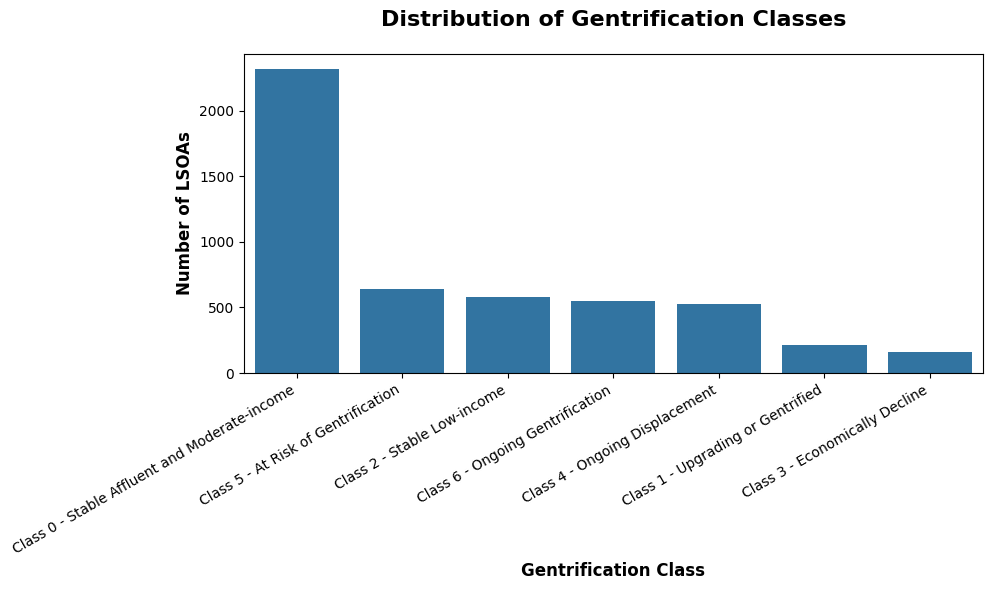

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of areas in each gentrification class
class_counts = df_7['gentrification_class'].value_counts(dropna=False).rename_axis('Class').reset_index(name='Count')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=class_counts, x='Class', y='Count')
plt.xticks(rotation=30, ha='right')
plt.title('Distribution of Gentrification Classes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gentrification Class', fontsize=12, fontweight='bold')
plt.ylabel('Number of LSOAs', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
import geopandas as gpd

# Load LSOA boundary
gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp")

In [25]:
# Merge classification results
gdf = gdf.merge(df_7[['LSOA21CD', 'gentrification_class']], left_on='LSOA21CD',right_on='LSOA21CD', how='left')

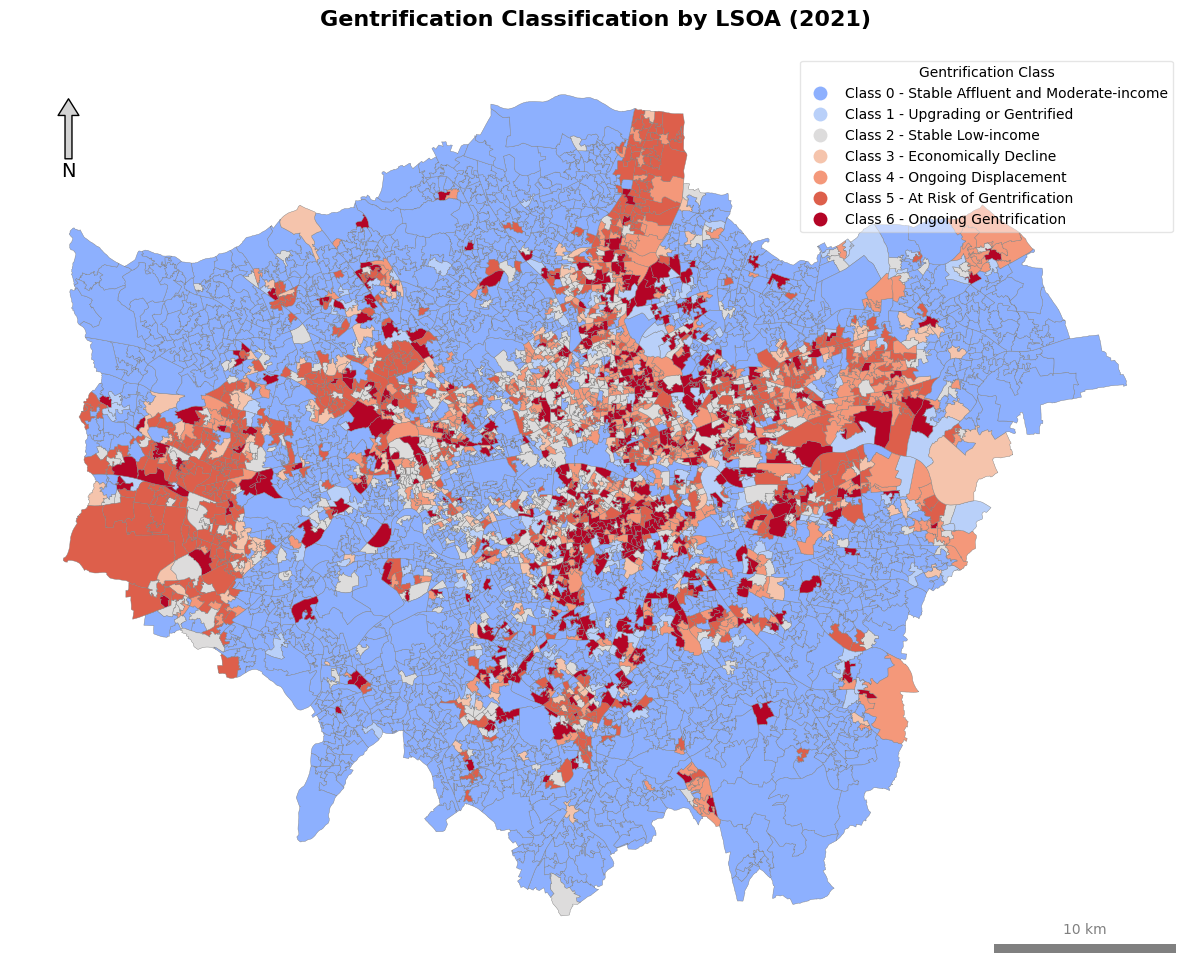

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib_scalebar.scalebar import ScaleBar

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the GeoDataFrame
gdf.plot(
    column='gentrification_class',
    cmap='coolwarm',
    vmin=-2,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'title': 'Gentrification Class'},
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "label": "Transitional Area"
    },
    ax=ax
)

leg = ax.get_legend()
leg.get_frame().set_alpha(0.5)

# Add scalebar (unit: meters for EPSG:27700)
scalebar = ScaleBar(
    dx=1,
    units='m',
    dimension='si-length',
    location='lower right',
    length_fraction=0.2,
    scale_loc='top',
    box_alpha=0.3,
    color='grey',   
    font_properties={'size': 10}
)
ax.add_artist(scalebar)

# Add grid lines
ax.grid(True, which='both', color='grey', linestyle='--', linewidth=0.5)

# Add north arrow
x, y, arrow_length = 0.05, 0.95, 0.08  # x/y in axis coordinates (0–1), arrow_length as fraction
ax.annotate('N',
            xy=(x, y),
            xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='lightgrey', width=5, headwidth=15),
            ha='center',
            va='center',
            fontsize=14,
            xycoords=ax.transAxes)

# Title and layout
ax.set_title("Gentrification Classification by LSOA (2021)", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()